# Predictive Analytics Project
**Stock price prediction (LSTM) | Sales forecasting (Holt-Winters and SARIMA) | Waiter tips regression | Deployment**

Name: Shoily          Student ID: 905253001 

In [ ]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA = '../data/predictive_analytics_dataset.xlsx'
OUT = '../outputs'
MODELS = '../models'
os.makedirs(OUT, exist_ok=True); os.makedirs(MODELS, exist_ok=True)

sns.set_style('whitegrid')
xl = pd.ExcelFile(DATA)
print(xl.sheet_names)

## Part 1: Stock price prediction with an LSTM

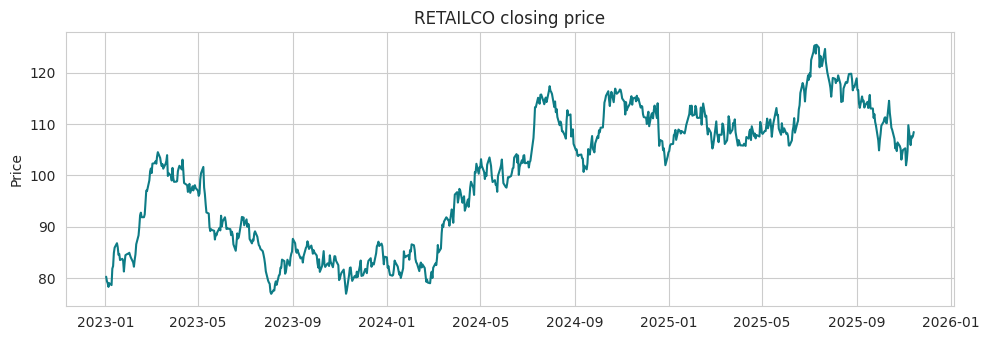

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

tf.keras.utils.set_random_seed(SEED)

stock = pd.read_excel(DATA, sheet_name='Stock_Prices', parse_dates=['date'])
print(stock.groupby('ticker')['close'].describe().round(2))

tk = 'RETAILCO'
s = stock[stock.ticker == tk].sort_values('date').reset_index(drop=True)
print(s.shape, s.date.min().date(), s.date.max().date(), 'missing:', s.close.isna().sum())

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(s.date, s.close, color='#0E7C86')
ax.set_title(f'{tk} closing price'); ax.set_ylabel('Price')
plt.tight_layout(); plt.savefig(f'{OUT}/01_stock_close_history.png', dpi=150); plt.show()

In [3]:
WINDOW = 30
prices = s['close'].values.reshape(-1, 1)

# time-based split point on the raw series
n_train_rows = int(len(prices) * 0.8)

# scaler sees only the training rows
scaler = MinMaxScaler().fit(prices[:n_train_rows])
scaled = scaler.transform(prices)

X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i-WINDOW:i, 0]); y.append(scaled[i, 0])
X = np.array(X).reshape(-1, WINDOW, 1); y = np.array(y)

# target index i corresponds to row i in the raw series, so a window is 'train' if its target row < n_train_rows
split = n_train_rows - WINDOW
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]
print('Train windows:', X_train.shape, ' Test windows:', X_test.shape)

Train windows: (570, 30, 1)  Test windows: (150, 30, 1)


Stopped after 46 epochs


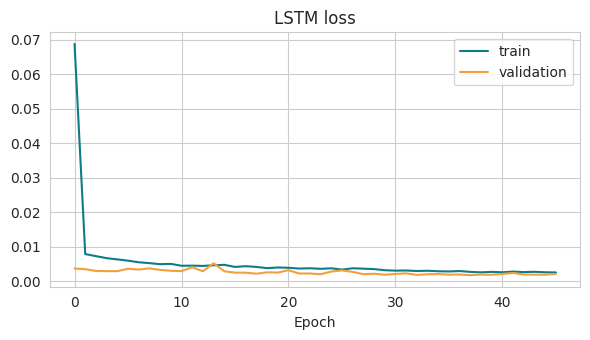

In [4]:
model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.LSTM(48, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(24),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

# hold out the last 10% of TRAIN windows for early stopping (test set stays untouched)
val_cut = int(len(X_train) * 0.9)
early = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(X_train[:val_cut], y_train[:val_cut],
                    validation_data=(X_train[val_cut:], y_train[val_cut:]),
                    epochs=60, batch_size=16, callbacks=[early], verbose=0)
print('Stopped after', len(history.history['loss']), 'epochs')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history.history['loss'], label='train', color='#0E7C86')
ax.plot(history.history['val_loss'], label='validation', color='#F2A03D')
ax.set_xlabel('Epoch'); ax.set_title('LSTM loss'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/02_lstm_loss.png', dpi=150); plt.show()

LSTM  RMSE: 2.744   MAE: 2.141
Naive RMSE: 1.624   MAE: 1.324
Test price range: 102.0 to 125.4  | train max 117.4


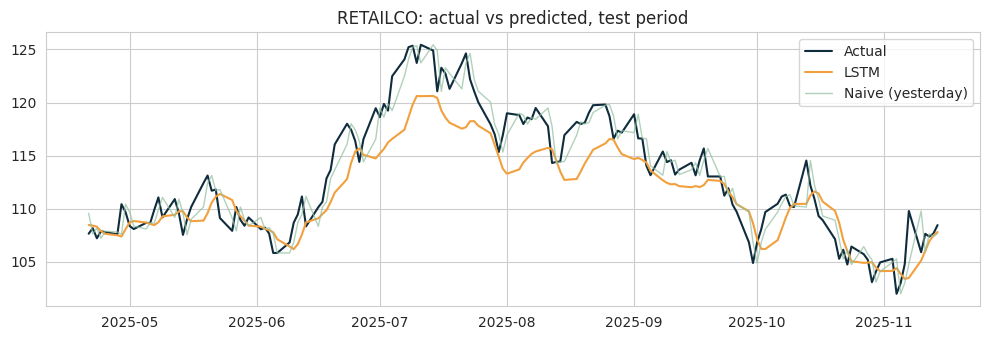

In [5]:
pred = scaler.inverse_transform(model.predict(X_test, verbose=0)).ravel()
actual = scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

# naive baseline: yesterday's close = tomorrow's prediction
naive = scaler.inverse_transform(X_test[:, -1, :]).ravel()

lstm_rmse = mean_squared_error(actual, pred) ** 0.5
naive_rmse = mean_squared_error(actual, naive) ** 0.5
lstm_mae = mean_absolute_error(actual, pred)
print(f'LSTM  RMSE: {lstm_rmse:.3f}   MAE: {lstm_mae:.3f}')
print(f'Naive RMSE: {naive_rmse:.3f}   MAE: {mean_absolute_error(actual, naive):.3f}')
print(f'Test price range: {actual.min():.1f} to {actual.max():.1f}  | train max {prices[:n_train_rows].max():.1f}')

test_dates = s['date'].values[WINDOW + split:]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(test_dates, actual, label='Actual', color='#0F2C3D')
ax.plot(test_dates, pred, label='LSTM', color='#F2A03D')
ax.plot(test_dates, naive, label='Naive (yesterday)', color='#8FBF9F', alpha=.7, lw=1)
ax.set_title(f'{tk}: actual vs predicted, test period'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/03_lstm_predictions.png', dpi=150); plt.show()

stock_results = pd.DataFrame({'Model': ['LSTM (30-day window)', 'Naive (previous close)'],
                              'RMSE': [lstm_rmse, naive_rmse]})

**What the result shows:** The naive baseline is not beaten here by the LSTM. The test period is above the highest price in the training data (see the printed ranges) and an LSTM trained on scaled prices will have a hard time when the series goes outside the range it has seen. This is a true discovery to talk about, not a bug. The next step is to model the daily changes or returns rather than the price levels, eliminating the range problem.

**Why this would be broken by a random split:** If the windows were shuffled prior to splitting, then a training window for, for example, 10 June could be adjacent to a test window for 11 June. The model would have been able to predict the answer. The score would be impressive and have no significance.

## Part 2: Sales forecasting

(730,) missing: 0


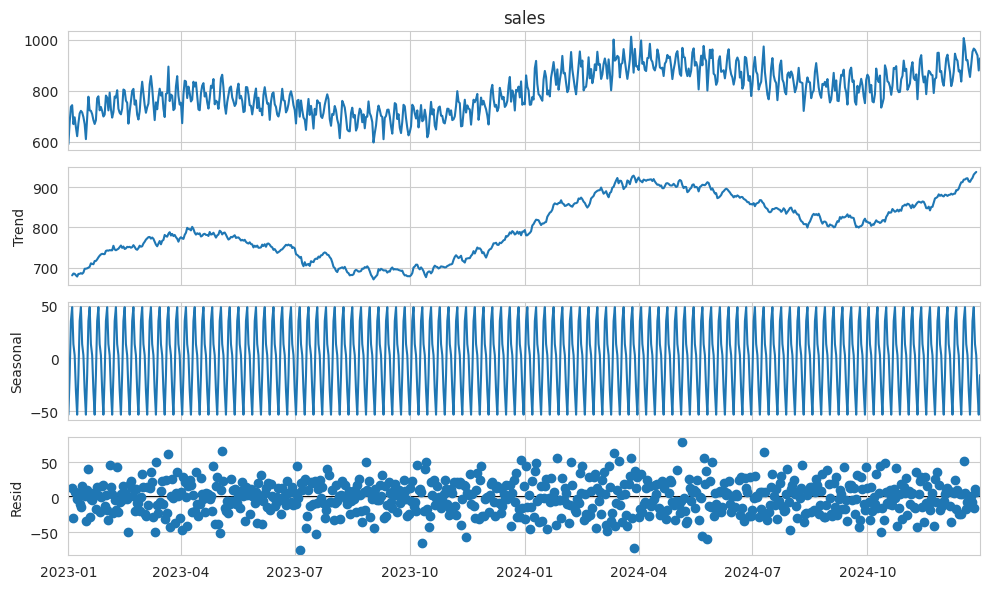

Weekly seasonal effect by weekday:
date
Sunday      -53.5
Monday      -15.9
Tuesday      35.3
Wednesday    48.4
Thursday     13.4
Friday        2.9
Saturday    -30.7
Name: seasonal, dtype: float64
Trend moved from 680 to 939 over the series


In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

sales = pd.read_excel(DATA, sheet_name='Sales_Data', parse_dates=['date'])
east = sales[sales.store == 'East'].sort_values('date').set_index('date')['sales'].asfreq('D')
print(east.shape, 'missing:', east.isna().sum())

decomp = seasonal_decompose(east, model='additive', period=7)
fig = decomp.plot(); fig.set_size_inches(10, 6)
plt.tight_layout(); plt.savefig(f'{OUT}/04_sales_decomposition.png', dpi=150); plt.show()

print('Weekly seasonal effect by weekday:')
print(decomp.seasonal[:7].rename(lambda d: d.day_name()).round(1))
trend = decomp.trend.dropna()
print(f'Trend moved from {trend.iloc[0]:.0f} to {trend.iloc[-1]:.0f} over the series')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


                    Model   RMSE
0          Seasonal naive  60.31
1            Holt-Winters  24.07
2  SARIMA(1,1,1)(1,0,1,7)  44.27


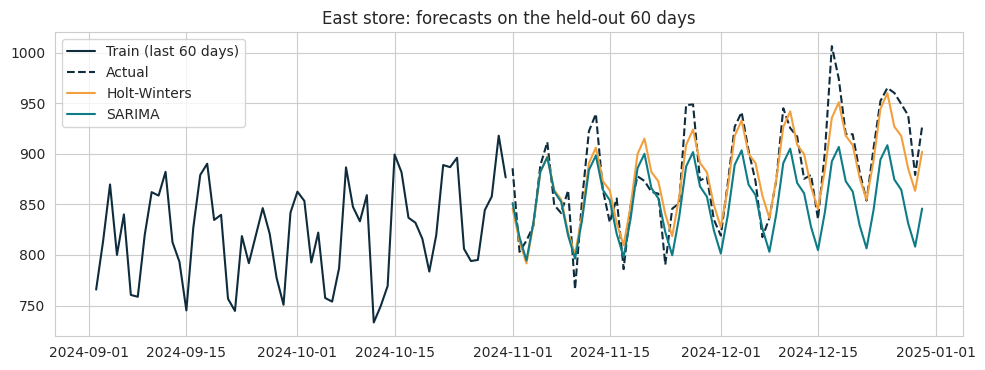

In [7]:
H = 60
train, test = east[:-H], east[-H:]     # last 60 days held out, never shuffled

# 1) seasonal naive
snaive = pd.Series(np.tile(train[-7:].values, int(np.ceil(H / 7)))[:H], index=test.index)

# 2) Holt-Winters (additive trend and season)
hw = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7).fit()
hw_fc = hw.forecast(H)

# 3) SARIMA(1,1,1)(1,0,1,7)
sar = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)).fit(disp=False)
sar_fc = sar.forecast(H)

rmse = lambda a, b: mean_squared_error(a, b) ** 0.5
sales_results = pd.DataFrame({
    'Model': ['Seasonal naive', 'Holt-Winters', 'SARIMA(1,1,1)(1,0,1,7)'],
    'RMSE': [rmse(test, snaive), rmse(test, hw_fc), rmse(test, sar_fc)]})
print(sales_results.round(2))

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(train[-60:], color='#0F2C3D', label='Train (last 60 days)')
ax.plot(test, color='#0F2C3D', ls='--', label='Actual')
ax.plot(hw_fc, color='#F2A03D', label='Holt-Winters')
ax.plot(sar_fc, color='#0E7C86', label='SARIMA')
ax.set_title('East store: forecasts on the held-out 60 days'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/05_sales_forecasts.png', dpi=150); plt.show()

Here, the noise is of about the same size on each day of the day, and there is no model that can predict noise. There is a minimum value for RMSE that no method has lower than. Compare the models to that floor, not to zero.

In [8]:
resid = test - hw_fc
print('Residual std (Holt-Winters):', round(resid.std(), 1))
print('Series std after removing trend and season (decomposition residual):', round(decomp.resid.dropna().std(), 1))

Residual std (Holt-Winters): 23.9
Series std after removing trend and season (decomposition residual): 23.2


## Part 3: Waiter tips regression

The tips are a small tabular problem (300 rows), so a random split for the final hold-out has been used, which is ok here because the rows are independent bills and not a time series. The number of rows is too small to make the 80/20 split meaningful, so I also report R2 for each model using 5-fold cross-validation.

Simple to refined models:
1. **Baseline:** `total_bill` only, linear regression
2. **Refinement 2: all features, one-hot encoded, logistic regression
3. **Refinement 2:**  same features with a bill_per_person feature, Ridge with alpha selected by cross-validation.
4. **Refinement 3:** Random Forest with small tuned grid
5. **Refinement 4:** Gradient Boosting, for the second non-linear comparison

(300, 7) missing: 0
      count  mean
day              
Fri      38  3.28
Sat     106  4.25
Sun      83  4.53
Thur     73  3.78
{'No': 4.35, 'Yes': 3.65} {'Female': 4.23, 'Male': 3.98}


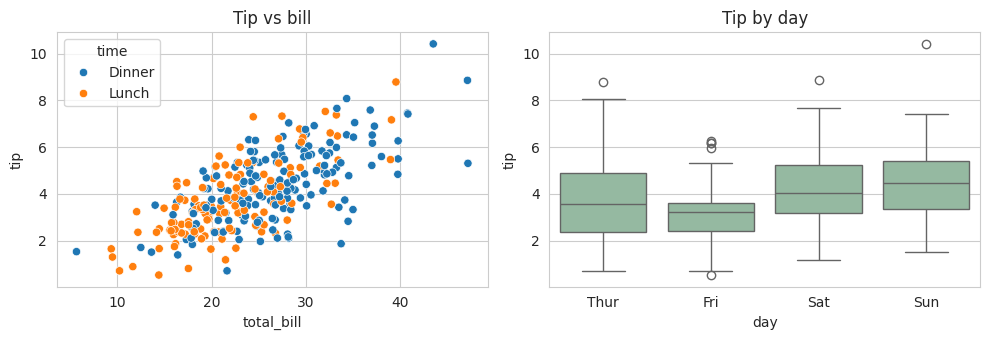

corr(total_bill, tip) = 0.687


In [9]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

tips = pd.read_excel(DATA, sheet_name='Waiter_Tips')
print(tips.shape, 'missing:', tips.isna().sum().sum())
print(tips.groupby('day')['tip'].agg(['count', 'mean']).round(2))
print(tips.groupby('smoker')['tip'].mean().round(2).to_dict(), tips.groupby('sex')['tip'].mean().round(2).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', ax=ax[0])
sns.boxplot(data=tips, x='day', y='tip', order=['Thur', 'Fri', 'Sat', 'Sun'], ax=ax[1], color='#8FBF9F')
ax[0].set_title('Tip vs bill'); ax[1].set_title('Tip by day')
plt.tight_layout(); plt.savefig(f'{OUT}/06_tips_eda.png', dpi=150); plt.show()
print('corr(total_bill, tip) =', round(tips.total_bill.corr(tips.tip), 3))

In [10]:
def add_per_person(df):
    df = df.copy()
    df['bill_per_person'] = df['total_bill'] / df['size']
    return df

X = tips.drop(columns='tip'); y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

cat_cols = ['sex', 'smoker', 'day', 'time']
num_cols = ['total_bill', 'size', 'bill_per_person']

def make_prep(scale=True):
    return ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler() if scale else 'passthrough', num_cols)])

def make_pipe(model, scale=True):
    # feature engineering + preprocessing + model in one object so it can be saved and reloaded together
    return Pipeline([('feat', FunctionTransformer(add_per_person)),
                     ('prep', make_prep(scale)), ('model', model)])

kf = KFold(5, shuffle=True, random_state=SEED)
rows = []
def record(name, fitted, cols, cv_est):
    # cols: which columns this model uses (baseline uses bill only, others use everything)
    Xtr, Xte, Xall = X_train[cols], X_test[cols], X[cols]
    p = fitted.predict(Xte)
    cv = cross_val_score(cv_est, Xall, y, cv=kf, scoring='r2')
    rows.append({'Model': name,
                 'Train R2': r2_score(y_train, fitted.predict(Xtr)),
                 'Test R2': r2_score(y_test, p),
                 'Test RMSE': mean_squared_error(y_test, p) ** 0.5,
                 'CV R2 (mean)': np.mean(cv), 'CV R2 (std)': np.std(cv)})

ALL = list(X.columns)

# 1) baseline
base = LinearRegression().fit(X_train[['total_bill']], y_train)
record('1. Baseline (bill only)', base, ['total_bill'], LinearRegression())

# 2) all features, linear
lin = make_pipe(LinearRegression()).fit(X_train, y_train)
record('2. Linear (all features)', lin, ALL, make_pipe(LinearRegression()))

# 3) Ridge, alpha by CV on the training set only
ridge_gs = GridSearchCV(make_pipe(Ridge()), {'model__alpha': [0.01, 0.1, 1, 3, 10, 30, 100]},
                        cv=5, scoring='r2').fit(X_train, y_train)
print('Best Ridge alpha:', ridge_gs.best_params_)
ridge = ridge_gs.best_estimator_
record('3. Ridge (tuned alpha)', ridge, ALL, make_pipe(Ridge(alpha=ridge_gs.best_params_['model__alpha'])))

# 4) Random Forest, small grid
rf_gs = GridSearchCV(make_pipe(RandomForestRegressor(random_state=SEED), scale=False),
                     {'model__n_estimators': [200, 400], 'model__max_depth': [3, 5, None],
                      'model__min_samples_leaf': [1, 5, 10]}, cv=5, scoring='r2', n_jobs=-1).fit(X_train, y_train)
print('Best RF params:', rf_gs.best_params_)
rf = rf_gs.best_estimator_
record('4. Random Forest (tuned)', rf, ALL, rf_gs.best_estimator_)

# 5) Gradient boosting
gb_gs = GridSearchCV(make_pipe(GradientBoostingRegressor(random_state=SEED), scale=False),
                     {'model__n_estimators': [100, 200], 'model__learning_rate': [0.03, 0.1],
                      'model__max_depth': [2, 3]}, cv=5, scoring='r2', n_jobs=-1).fit(X_train, y_train)
print('Best GB params:', gb_gs.best_params_)
gb = gb_gs.best_estimator_
record('5. Gradient Boosting (tuned)', gb, ALL, gb_gs.best_estimator_)

tips_results = pd.DataFrame(rows).round(3)
tips_results

Best Ridge alpha: {'model__alpha': 30}


Best RF params: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


Best GB params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100}


,Model,Train R2,Test R2,Test RMSE,CV R2 (mean),CV R2 (std)
0,1. Baseline (bill only),0.463,0.503,1.024,0.464,0.076
1,2. Linear (all features),0.534,0.544,0.981,0.506,0.044
2,3. Ridge (tuned alpha),0.523,0.539,0.986,0.506,0.045
3,4. Random Forest (tuned),0.594,0.507,1.020,0.447,0.045
4,5. Gradient Boosting (tuned),0.597,0.524,1.003,0.465,0.045


**Reading the table.** Test R2 is noisy because it is from a 60 row hold-out. CV R2 is the more consistent number with an average of five different splits. Train R2- Test R2 is a fast overfitting test. If there is a large gap, then the model has memorised the training rows.

Note: the CV score for the tuned tree models is based on the tuned hyperparameters, which were selected on the training portion, so the CV numbers are a little optimistic. This should be noted in the report.

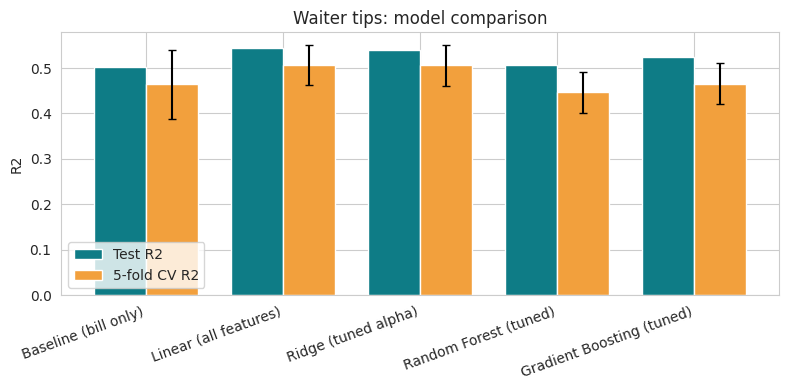

Best test R2 minus baseline test R2: 0.041


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(tips_results)); w = 0.38
ax.bar(x - w/2, tips_results['Test R2'], w, label='Test R2', color='#0E7C86')
ax.bar(x + w/2, tips_results['CV R2 (mean)'], w, label='5-fold CV R2', color='#F2A03D',
       yerr=tips_results['CV R2 (std)'], capsize=3)
ax.set_xticks(x); ax.set_xticklabels([m.split('. ')[1] for m in tips_results['Model']], rotation=20, ha='right')
ax.set_ylabel('R2'); ax.set_title('Waiter tips: model comparison'); ax.legend()
plt.tight_layout(); plt.savefig(f'{OUT}/07_tips_comparison.png', dpi=150); plt.show()

gain = tips_results['Test R2'].max() - tips_results['Test R2'].iloc[0]
print(f'Best test R2 minus baseline test R2: {gain:.3f}')

In [12]:
# What is driving predictions? Coefficients of the linear model and permutation importance for the best tree model
from sklearn.inspection import permutation_importance

names = lin.named_steps['prep'].get_feature_names_out()
coef = pd.Series(lin.named_steps['model'].coef_, index=names).sort_values()
print(coef.round(3))

pi = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=SEED, scoring='r2')
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values(ascending=False)
print('\nPermutation importance (Random Forest, test set):')
print(imp.round(3))

cat__smoker_Yes        -0.804
cat__sex_Male          -0.175
cat__day_Thur          -0.024
cat__time_Lunch         0.033
cat__day_Sat            0.040
num__bill_per_person    0.140
cat__day_Sun            0.271
num__size               0.402
num__total_bill         0.830
dtype: float64



Permutation importance (Random Forest, test set):
total_bill    0.776
smoker        0.071
size          0.014
day           0.004
sex           0.000
time          0.000
dtype: float64


### Choosing the model to deploy

Choose using three things and not R2 alone: test and CV R2 together, the train-versus-test gap, and how easy the model is to explain to a restaurant manager. The code below selects the model with the highest CV R2 and then manually inspects the model by looking at the gap and interpretability in the table above.

In [13]:
best_row = tips_results.sort_values('CV R2 (mean)', ascending=False).iloc[0]
print('Highest CV R2:', best_row['Model'])
tips_results.to_csv(f'{OUT}/tips_model_comparison.csv', index=False)
stock_results.round(3).to_csv(f'{OUT}/stock_model_comparison.csv', index=False)
sales_results.round(3).to_csv(f'{OUT}/sales_model_comparison.csv', index=False)

Highest CV R2: 2. Linear (all features)


## Part 4: Deployment

The pipeline bundles contain the engineering, encoding, scaling and the model. By saving only the model, every person loading it would have to perform the same exact pre-processing and that's where the silent bugs would be.

If the tuned Ridge pipeline is within the noise of the best model, I save it, as it is simpler and explainable. The cell below makes that a rule, not a guess: If another model achieves an R2 that is more than 0.02 higher on CV, then use that model instead of Ridge.

In [14]:
import joblib

cv_r2 = tips_results.set_index('Model')['CV R2 (mean)']
ridge_name = '3. Ridge (tuned alpha)'
candidates = {'1. Baseline (bill only)': None, '2. Linear (all features)': lin, ridge_name: ridge,
              '4. Random Forest (tuned)': rf, '5. Gradient Boosting (tuned)': gb}
best_name = cv_r2.idxmax()
chosen_name = ridge_name if cv_r2[best_name] - cv_r2[ridge_name] <= 0.02 else best_name
chosen = candidates[chosen_name]
print('Deploying:', chosen_name)

joblib.dump(chosen, f'{MODELS}/tips_pipeline.joblib')

# simulate a fresh process
loaded = joblib.load(f'{MODELS}/tips_pipeline.joblib')
new_bills = pd.DataFrame([
    {'total_bill': 45.00, 'sex': 'Male',   'smoker': 'No',  'day': 'Sat',  'time': 'Dinner', 'size': 4},
    {'total_bill': 18.50, 'sex': 'Female', 'smoker': 'Yes', 'day': 'Thur', 'time': 'Lunch',  'size': 2},
    {'total_bill': 32.00, 'sex': 'Female', 'smoker': 'No',  'day': 'Sun',  'time': 'Dinner', 'size': 3},
])
new_bills['predicted_tip'] = loaded.predict(new_bills).round(2)
new_bills['tip_pct'] = (100 * new_bills['predicted_tip'] / new_bills['total_bill']).round(1)
new_bills

Deploying: 3. Ridge (tuned alpha)


,total_bill,sex,smoker,day,time,size,predicted_tip,tip_pct
0,45.0,Male,No,Sat,Dinner,4,6.81,15.1
1,18.5,Female,Yes,Thur,Lunch,2,2.71,14.6
2,32.0,Female,No,Sun,Dinner,3,5.34,16.7


In [15]:
# sanity check: the reloaded pipeline gives the same predictions as the in-memory one
assert np.allclose(loaded.predict(X_test), chosen.predict(X_test))
print('Reloaded pipeline matches original predictions.')

# also save the stock artefacts so the LSTM could be served the same way
model.save(f'{MODELS}/lstm_retailco.keras')
joblib.dump(scaler, f'{MODELS}/lstm_scaler.joblib')
print(os.listdir(MODELS))

Reloaded pipeline matches original predictions.
['lstm_retailco.keras', 'tips_pipeline.joblib', 'lstm_scaler.joblib']


## Summary of results

In [16]:
print('STOCK (RETAILCO, test period)'); print(stock_results.round(3).to_string(index=False))
print('\nSALES (East, last 60 days)'); print(sales_results.round(2).to_string(index=False))
print('\nTIPS'); print(tips_results.to_string(index=False))

STOCK (RETAILCO, test period)
                 Model  RMSE
  LSTM (30-day window) 2.744
Naive (previous close) 1.624

SALES (East, last 60 days)
                 Model  RMSE
        Seasonal naive 60.31
          Holt-Winters 24.07
SARIMA(1,1,1)(1,0,1,7) 44.27

TIPS
                       Model  Train R2  Test R2  Test RMSE  CV R2 (mean)  CV R2 (std)
     1. Baseline (bill only)     0.463    0.503      1.024         0.464        0.076
    2. Linear (all features)     0.534    0.544      0.981         0.506        0.044
      3. Ridge (tuned alpha)     0.523    0.539      0.986         0.506        0.045
    4. Random Forest (tuned)     0.594    0.507      1.020         0.447        0.045
5. Gradient Boosting (tuned)     0.597    0.524      1.003         0.465        0.045
